# Phase VI Part 1: biological function and pathway enrichment analysis 
+ In this notebook, DICE genes that were identified via betweennnes which used distance as weight and eigenvector centrality which used correlation as weight will be analyzed for enrichment analysis. 

In [1]:
import gseapy as gp
import pandas as pd
import json

In [2]:
dice_genes = pd.read_csv("../data/results/dice_genes.tsv", sep="\t", usecols=[0])
dice_genes = list(dice_genes["Unnamed: 0"])
n = len(dice_genes)

In [3]:
# Upload GO gmt file
go_set = "../data/enrichment/go.gmt"
kegg_set = "../data/enrichment/kegg.gmt"

In [4]:
# Upload the GO Terms and KEGG Term Mappings
kegg_map = open("../data/enrichment/kegg_mapping.json")
go_map = open(("../data/enrichment/go_mapping.json"))
kegg_terms_mapping = json.load(kegg_map)
go_term_mapping = json.load(go_map)

In [5]:
enr_go = gp.enrich(gene_list=dice_genes, # or gene_list=glist
                 gene_sets=go_set, 
                 background=None,
                 outdir=None,
                 verbose=True)

2026-03-06 01:28:39,510 [INFO] User defined gene sets is given: ../data/enrichment/go.gmt
2026-03-06 01:28:39,648 [INFO] Run: go.gmt
2026-03-06 01:28:46,823 [INFO]   Background is not set! Use all 19591 genes in go.gmt.
2026-03-06 01:28:47,905 [INFO] Done.


In [6]:
enr_go.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,go.gmt,GO:0000014,1/12,0.563413,0.712812,1.824340,1.046701,DCLRE1C
1,go.gmt,GO:0000018,21/141,0.000435,0.004136,2.519214,19.500262,RNF8;ACTL6A;TFRC;IL7R;MLH1;MBTD1;PTPRC;WRAP53;...
2,go.gmt,GO:0000019,1/7,0.383307,0.597461,3.228561,3.095928,MLH1
3,go.gmt,GO:0000022,1/12,0.563413,0.712812,1.824340,1.046701,RACGAP1
4,go.gmt,GO:0000027,8/29,0.000466,0.004371,5.556332,42.629571,NOP2;RPL5;MRM2;MDN1;BOP1;RPL11;RPF2;RPL24


In [7]:
# Save the results to a new df
results_go = enr_go.results
results_go.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,go.gmt,GO:0000014,1/12,0.563413,0.712812,1.824340,1.046701,DCLRE1C
1,go.gmt,GO:0000018,21/141,0.000435,0.004136,2.519214,19.500262,RNF8;ACTL6A;TFRC;IL7R;MLH1;MBTD1;PTPRC;WRAP53;...
2,go.gmt,GO:0000019,1/7,0.383307,0.597461,3.228561,3.095928,MLH1
3,go.gmt,GO:0000022,1/12,0.563413,0.712812,1.824340,1.046701,RACGAP1
4,go.gmt,GO:0000027,8/29,0.000466,0.004371,5.556332,42.629571,NOP2;RPL5;MRM2;MDN1;BOP1;RPL11;RPF2;RPL24


In [8]:
# Filter out results with less than 0.05 adjusted p value
results_go_filt = results_go[results_go['Adjusted P-value'] < 0.05].copy()
print(f"Number of significant results: {len(results_go_filt)}")
results_go_filt.head()

Number of significant results: 1490


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
1,go.gmt,GO:0000018,21/141,0.000435,0.004136,2.519214,19.500262,RNF8;ACTL6A;TFRC;IL7R;MLH1;MBTD1;PTPRC;WRAP53;...
4,go.gmt,GO:0000027,8/29,0.000466,0.004371,5.556332,42.629571,NOP2;RPL5;MRM2;MDN1;BOP1;RPL11;RPF2;RPL24
5,go.gmt,GO:0000028,8/24,0.000108,0.001275,7.242051,66.170493,RPS6;PRKDC;METTL17;RPS27L;RPSA;RPS14;FAU;RPS27
9,go.gmt,GO:0000049,18/81,0.000005,0.000086,4.116810,50.292394,SLFN13;RPUSD4;EIF2AK4;XPO5;TRMT11;TRMT1;NSUN2;...
11,go.gmt,GO:0000055,3/7,0.008459,0.045768,10.899323,52.017837,SDAD1;RAN;NUP88


In [9]:
# Map GO terms id to descriptions
results_go_filt["GO Term Name"] = results_go_filt["Term"].map(go_term_mapping)

In [10]:
# Add new overlap column and calculate the overlap ratio
results_go_filt["new_overlap"] = results_go_filt["Overlap"].str.split("/").str[0] + "/1132"
results_go_filt["new_overlap_rat"] = results_go_filt["Overlap"].apply(lambda x: int(x.split("/")[0]) / n)

# Reorder the df
results_go_filt = results_go_filt.iloc[:, [0, 1, 8, 9, 10,2,3,4,5,6,7]]

In [11]:
# Sort the results based on new overlap ratio
results_go_filt.sort_values("new_overlap_rat", ascending=False, inplace=True)

In [12]:
# Check the final df 
results_go_filt.head()

,Gene_set,Term,GO Term Name,new_overlap,new_overlap_rat,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
7636,go.gmt,GO:1990904,ribonucleoprotein complex,263/1132,0.197447,263/1144,7.704071e-77,2.008194e-73,4.980655,872.896156,MRPS26;MRPL28;ILF3;IMP3;WBP4;MRPL36;HNRNPA1;HN...
883,go.gmt,GO:0005739,mitochondrion,262/1132,0.196697,262/1782,9.631977e-37,4.430710e-34,2.768276,229.574712,COX7A2;MRPS26;ECHDC2;MRPL28;ILF3;AMACR;MRPL36;...
4224,go.gmt,GO:0043933,protein-containing complex organization,259/1132,0.194444,259/1964,1.947192e-28,5.075681e-26,2.405961,153.514751,TWF2;NDEL1;MDM2;PEX2;TBCA;TUBA1A;MED31;CLNS1A;...
6842,go.gmt,GO:0140513,nuclear protein-containing complex,257/1132,0.192943,257/1445,2.681752e-51,2.097130e-48,3.526056,410.592890,IMP3;SEC13;FANCE;SMAD9;PEX2;WBP4;BMI1;HNRNPAB;...
1071,go.gmt,GO:0006396,RNA processing,234/1132,0.175676,234/1459,1.175032e-38,6.125834e-36,3.040841,265.577784,ILF3;IMP3;WBP4;DDX18;HNRNPA1;DDX54;ZRANB2;KRI1...


In [13]:
# # Save GO encrichment analysis results
# results_go_filt.to_csv("../data/enrichment/dice_v1_go_results.tsv", sep="\t", index=False)

### Part 2: KEGG pathway enrichment analysis

In [14]:
enr_kegg = gp.enrich(gene_list=dice_genes, 
                 gene_sets=kegg_set, 
                 background=None,
                 outdir=None,
                 verbose=True)

2026-03-06 01:28:48,078 [INFO] User defined gene sets is given: ../data/enrichment/kegg.gmt
2026-03-06 01:28:48,108 [INFO] Run: kegg.gmt
2026-03-06 01:28:48,127 [INFO]   Background is not set! Use all 8011 genes in kegg.gmt.
2026-03-06 01:28:48,160 [INFO] Done.


In [15]:
# Save the results to a new df
results_kegg = enr_kegg.results
results_kegg.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,kegg.gmt,hsa00010,8/68,0.385450,0.666302,1.245102,1.187009,GAPDH;LDHA;ENO2;HK1;ALDOA;AKR1A1;ENO3;ACSS2
1,kegg.gmt,hsa00020,1/30,0.959906,1.000000,0.448678,0.018360,FH
2,kegg.gmt,hsa00030,6/30,0.077106,0.200218,2.357200,6.040485,TKT;ALDOA;PGD;PRPS1;G6PD;TALDO1
3,kegg.gmt,hsa00040,1/34,0.973914,1.000000,0.394884,0.010438,AKR1A1
4,kegg.gmt,hsa00051,4/33,0.434607,0.682569,1.351022,1.125824,ENOSF1;ALDOA;TSTA3;HK1


In [16]:
# Filter out results with less than 0.05 adjusted p value
results_kegg_filt = results_kegg[results_kegg['Adjusted P-value'] < 0.05].copy()
print(f"Number of significant results: {len(results_kegg_filt)}")
results_kegg_filt.head()

Number of significant results: 87


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
14,kegg.gmt,hsa00190,31/133,6.766341e-06,1.053596e-04,2.787061,33.175926,COX7A2;NDUFB3;NDUFS5;ATP6V0D1;NDUFB8;ATP6V1G1;...
71,kegg.gmt,hsa01521,16/79,5.158654e-03,2.226141e-02,2.324898,12.245424,MET;RPS6;BRAF;EIF4E2;AKT1;PLCG2;GSK3B;MAPK1;PR...
75,kegg.gmt,hsa03008,32/108,1.251214e-08,5.523215e-07,3.871911,70.455492,UTP15;IMP3;HEATR1;NOP56;WDR75;MDN1;NOP58;GAR1;...
76,kegg.gmt,hsa03010,85/158,7.938381e-44,2.452960e-41,11.377964,1129.172321,MRPL28;MRPL36;RPL41;MRPL17;RPL18A;MRPL16;RPL30...
77,kegg.gmt,hsa03013,39/180,3.142172e-06,6.472873e-05,2.543725,32.230510,EIF4E2;GEMIN2;NUP88;SEC13;XPO5;EIF2S1;EIF1B;CL...


In [17]:
# Map GO terms id to descriptions
results_kegg_filt["KEGG Pathway"] = results_kegg_filt["Term"].map(kegg_terms_mapping)

In [18]:
# Add new overlap column and calculate the overlap ratio
results_kegg_filt["new_overlap"] = results_kegg_filt["Overlap"].str.split("/").str[0] + "/1132"
results_kegg_filt["new_overlap_rat"] = results_kegg_filt["Overlap"].apply(lambda x: int(x.split("/")[0]) / n)

# Reorder the df
results_kegg_filt = results_kegg_filt.iloc[:, [0, 1, 8, 9, 10,2,3,4,5,6,7]]

In [19]:
# Sort the results based on new overlap ratio
results_kegg_filt.sort_values("new_overlap_rat", ascending=False, inplace=True)

In [20]:
# Check the final df
results_kegg_filt.head()

,Gene_set,Term,KEGG Pathway,new_overlap,new_overlap_rat,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
76,kegg.gmt,hsa03010,Ribosome - Homo sapiens (human),85/1132,0.063814,85/158,7.938381e-44,2.452960e-41,11.377964,1129.172321,MRPL28;MRPL36;RPL41;MRPL17;RPL18A;MRPL16;RPL30...
271,kegg.gmt,hsa05200,Pathways in cancer - Homo sapiens (human),76/1132,0.057057,76/531,1.039881e-03,5.950429e-03,1.535665,10.547942,MET;MDM2;BRAF;SP1;BCR;CRK;GSK3B;CBL;PRKCB;SMAD...
233,kegg.gmt,hsa05010,Alzheimer disease - Homo sapiens (human),76/1132,0.057057,76/369,7.098594e-10,7.311552e-08,2.440543,51.412363,NDUFB3;COX7A2;NDUFS5;PSMC2;BRAF;DDIT3;APP;EIF2...
236,kegg.gmt,hsa05016,Huntington disease - Homo sapiens (human),61/1132,0.045796,61/306,1.297446e-07,4.454565e-06,2.314838,36.707999,COX7A2;PSMC2;NDUFS5;NDUFB3;GPX7;BDNF;SP1;SOD2;...
247,kegg.gmt,hsa05131,Shigellosis - Homo sapiens (human),55/1132,0.041291,55/242,4.950624e-09,2.835406e-07,2.736195,52.326317,UBE2D2;MDM2;CRK;GSK3B;ARPC4;TRAF2;CTTN;PFN1;U2...


In [21]:
# # Save the kegg encrichment results
# results_kegg_filt.to_csv("../data/enrichment/dice_v1_kegg_results.tsv", sep="\t", index=False)

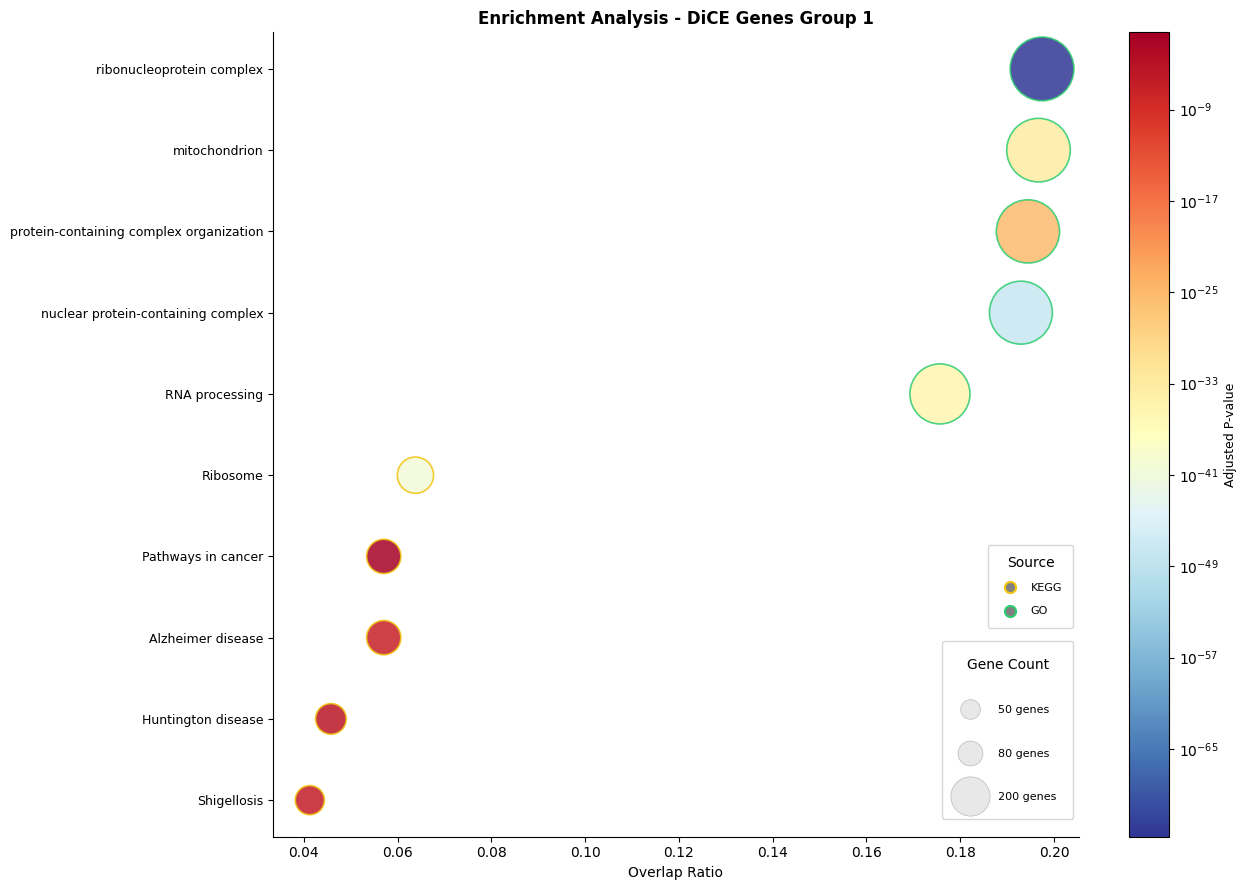

In [84]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
import numpy as np

# prep KEGG
top_kegg = results_kegg_filt.sort_values('new_overlap_rat', ascending=False).head(5).copy()
top_kegg['KEGG Pathway'] = top_kegg['KEGG Pathway'].str.replace(' - Homo sapiens (human)', '', regex=False)
top_kegg['label'] = top_kegg['KEGG Pathway']
top_kegg['source'] = 'KEGG'

# prep GO
top_go = results_go_filt.sort_values('new_overlap_rat', ascending=False).head(5).copy()
top_go['label'] = top_go['GO Term Name']
top_go['source'] = 'GO'

# join
combined = pd.concat([top_kegg, top_go], ignore_index=True)
combined = combined.sort_values('new_overlap_rat', ascending=True).reset_index(drop=True)

source_colors = {'KEGG': '#f1c40f', 'GO': '#2ecc71'}

norm = LogNorm(vmin=combined['Adjusted P-value'].min(),
               vmax=combined['Adjusted P-value'].max())

fig, ax = plt.subplots(figsize=(13, 9))

for source, group in combined.groupby('source'):
    idx = group.index
    gc = group['Overlap'].apply(lambda x: int(x.split('/')[0]))
    ax.scatter(
        group['new_overlap_rat'], idx,
        s=gc * 8,
        c=group['Adjusted P-value'],
        cmap='RdYlBu_r',
        norm=norm,
        edgecolors=source_colors[source],
        linewidth=1.2,
        alpha=0.85,
        label=source
    )

ax.set_yticks(range(len(combined)))
ax.set_yticklabels(combined['label'], fontsize=9)
ax.set_xlabel('Overlap Ratio', fontsize=10)
ax.set_title('Enrichment Analysis - DiCE Genes Group 1', fontsize=12, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=norm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Adjusted P-value', fontsize=9)

# source legend
source_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markeredgecolor='#f1c40f', markeredgewidth=1.5,
           markersize=8, label='KEGG'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markeredgecolor='#2ecc71', markeredgewidth=1.5,
           markersize=8, label='GO')
]

# size legend
size_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey',
           markeredgecolor='grey', markeredgewidth=0.5, alpha=0.5,
           markersize=np.sqrt(size*4), label=f'{size} genes')
    for size in [50, 80, 200]
]

legend2 = ax.legend(handles=size_handles, title='Gene Count',
                    bbox_to_anchor=(1, 0.25), fontsize=8,
                    frameon=True, labelspacing=3,
                    borderpad=1.5, handletextpad=1.5)

legend1 = ax.legend(handles=source_handles, title='Source',
                    bbox_to_anchor=(1, 0.37), fontsize=8,
                    frameon=True, labelspacing=1.2, borderpad=1)

ax.add_artist(legend2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('enrichment_dotplot_group1.png', dpi=300, bbox_inches='tight')
plt.show()